In [6]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)
print(data_air.keys())

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
dict_keys(['time_years', 'time_centered', 'Year', 'Month', 'Monthly_Anomaly', 'Monthly_Anomaly_Unc', 'Annual_Anomaly', 'Annual_Anomaly_Unc', 'Five_Year_Anomaly', 'Five_Year_Anomaly_Unc', 'Ten_Year_Anomaly', 'Ten_Year_Anomaly_Unc', 'Twenty_Year_Anomaly', 'Twenty_Year_Anomaly_Unc'])
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


In [3]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [4]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 20 - 10

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 1
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = (cube[0] * 0.002) - 0.001
    params[1] = (cube[1] * 0.2) - 0.1
    params[2] = (cube[2] * 4) - 2

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = (cube[2] * 2.0) - 2.0
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [5]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7251..-81416.7251]*| it/evals=4880/5466 eff=96.3285% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5499
[ultranest]   logZ = -8.143e+04 +- 0.1119
[ultranest] Effective samples strategy satisfied (ESS = 1249.0, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81425.586 +- 0.175
  single instance: logZ = -81425.586 +- 0.145
  bootstrapped   : logZ = -81425.605 +- 0.172
  tail           : logZ = +- 0.032
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3449│ ▁ ▁ ▁▁▁▁▁▁▁▂▃▃▅▅▅▆▇▇▇▇▇▆▄▃▂▂▂▂▁▁▁▁▁▁▁ │0.3529    0.3492 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4405..-74211.4405]*| it/evals=5040/5634 eff=96.2935% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5648
[ultranest]   logZ = -7.422e+04 +- 0.1221
[ultranest] Effective samples strategy satisfied (ESS = 1257.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.12 tail:0.03 total:0.13 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74220.678 +- 0.189
  single instance: logZ = -74220.678 +- 0.148
  bootstrapped   : logZ = -74220.673 +- 0.186
  tail           : logZ = +- 0.033
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31505│ ▁   ▁▁▁▁▁▂▂▂▄▄▅▄▇▇▇▇▆▅▆▄▄▃▃▁▁▁▁▁▁▁▁▁▁ │0.32315    0.31917 +- 0.00097

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior .

[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6265..-20185.6265]*| it/evals=9080/12445 eff=75.3840% N=400    0   0 
[ultranest] Likelihood function evaluations: 12485
[ultranest]   logZ = -2.02e+04 +- 0.1633
[ultranest] Effective samples strategy satisfied (ESS = 1631.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20203.767 +- 0.390
  single instance: logZ = -20203.767 +- 0.207
  bootstrapped   : logZ = -20203.780 +- 0.390
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009916│ ▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▆▇▅▅▃▃▂▂▂▁▁▁▁▁▁▁▁▁ │0.010137    0.010022 +- 0.000028
    b                   : -0.9828│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▅▅▆▇▇▇▆▆▆▅▄▃▃▂▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8230..-18230.8230]*| it/evals=9160/12480 eff=75.8278% N=400   00 0 0  
[ultranest] Likelihood function evaluations: 12504
[ultranest]   logZ = -1.825e+04 +- 0.1468
[ultranest] Effective samples strategy satisfied (ESS = 1650.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.05 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18249.158 +- 0.247
  single instance: logZ = -18249.158 +- 0.208
  bootstrapped   : logZ = -18249.149 +- 0.246
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009027│ ▁▁▁ ▁▁▁▁▁▂▃▃▄▅▇▇▇▇▇▇▇▆▅▄▃▂▁▁▁▁▁▁▁   ▁ │0.009271    0.009145 +- 0.000027
    b                   : -0.9138│ ▁     ▁▁▁▁▁▁▂▃▃▄▆▇▇▇▆▇▇▆▅▃▂▂▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3774..-2138.3771]*| it/evals=10960/18418 eff=60.8281% N=400   0    00 0  
[ultranest] Likelihood function evaluations: 18418
[ultranest]   logZ = -2161 +- 0.1979
[ultranest] Effective samples strategy satisfied (ESS = 1885.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.51, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2161.152 +- 0.317
  single instance: logZ = -2161.152 +- 0.231
  bootstrapped   : logZ = -2161.148 +- 0.317
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009903│ ▁ ▁ ▁▁▁▁▁▁▁▁▂▃▄▄▆▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁  ▁ │0.00010506    0.00010215 +- 0.00000060
    b                   : -0.01204│ ▁

[ultranest] Explored until L=-2e+03  948.94 [-1949.0048..-1949.0048]*| it/evals=10800/18326 eff=60.2477% N=400   0  0 0  0  
[ultranest] Likelihood function evaluations: 18395
[ultranest]   logZ = -1971 +- 0.17
[ultranest] Effective samples strategy satisfied (ESS = 1869.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1971.458 +- 0.427
  single instance: logZ = -1971.458 +- 0.229
  bootstrapped   : logZ = -1971.417 +- 0.427
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008725│ ▁▁▁▁▁▁▁▁▁▂▃▂▃▅▆▆▇▇▇▇▇▇▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁ │0.00009220    0.00008969 +- 0.00000057
    b                   : -0.01028│ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▄▇▇▆▆▇▇▆▅▅▃▂▂▂▁▁▁

[ultranest] Explored until L=-2e+03  681.17 [-1681.2166..-1681.2165]*| it/evals=10040/90547 eff=11.1374% N=400   0  0 
[ultranest] Likelihood function evaluations: 90568
[ultranest]   logZ = -1702 +- 0.1861
[ultranest] Effective samples strategy satisfied (ESS = 1897.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1701.730 +- 0.399
  single instance: logZ = -1701.730 +- 0.218
  bootstrapped   : logZ = -1701.706 +- 0.399
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02992│ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▆▇▇▆▆▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁ │0.03714    0.03338 +- 0.00093
    b                   : 0.02151│ ▁▁▁▁▁▁▁▁▂▂▂▃▄▄▅▆▅▇▇▇▇▅▄▄▃▃▃▁▂▁▁▁▁▁▁▁▁ │0.02268  

[ultranest] Explored until L=-2e+03  687.33 [-1687.3830..-1687.3830]*| it/evals=9960/95189 eff=10.5075% N=400 0     0 
[ultranest] Likelihood function evaluations: 95252
[ultranest]   logZ = -1708 +- 0.1417
[ultranest] Effective samples strategy satisfied (ESS = 1837.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1707.715 +- 0.320
  single instance: logZ = -1707.715 +- 0.218
  bootstrapped   : logZ = -1707.725 +- 0.320
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0310│ ▁ ▁▁▁▁▁▁▁▁▃▂▃▄▆▆▆▆▇▇▇▆▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁ │0.0394    0.0352 +- 0.0010
    b                   : 0.02058│ ▁▁▁▁▁▁▁▂▂▂▂▃▄▄▇▇▇▇▆▆▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁ ▁ │0.02187    

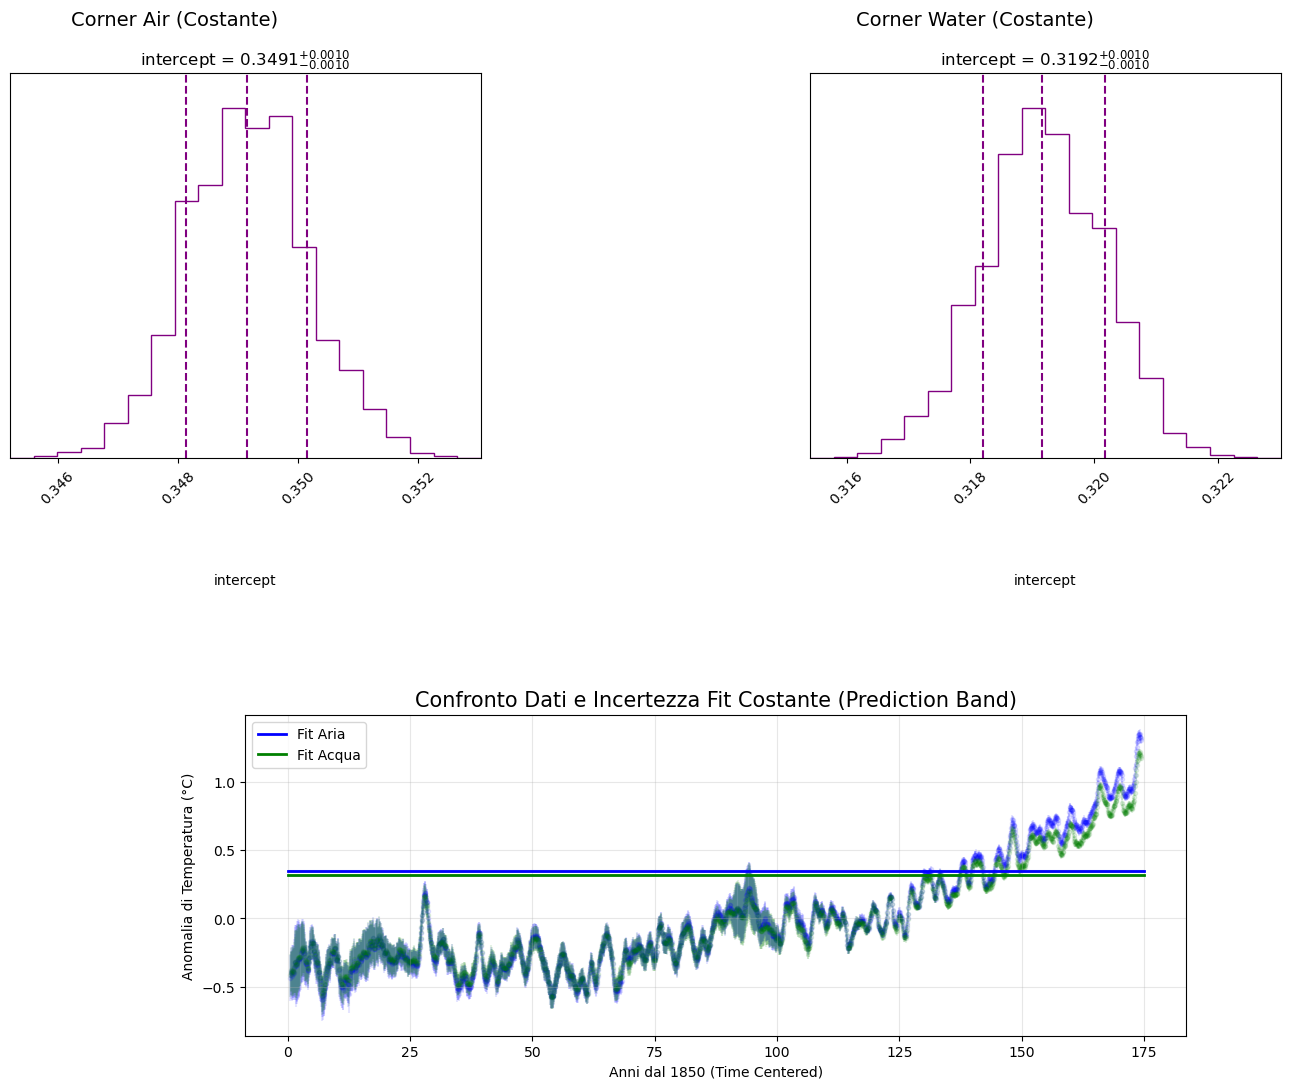

In [8]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)
    
    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        val = samples[i]
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

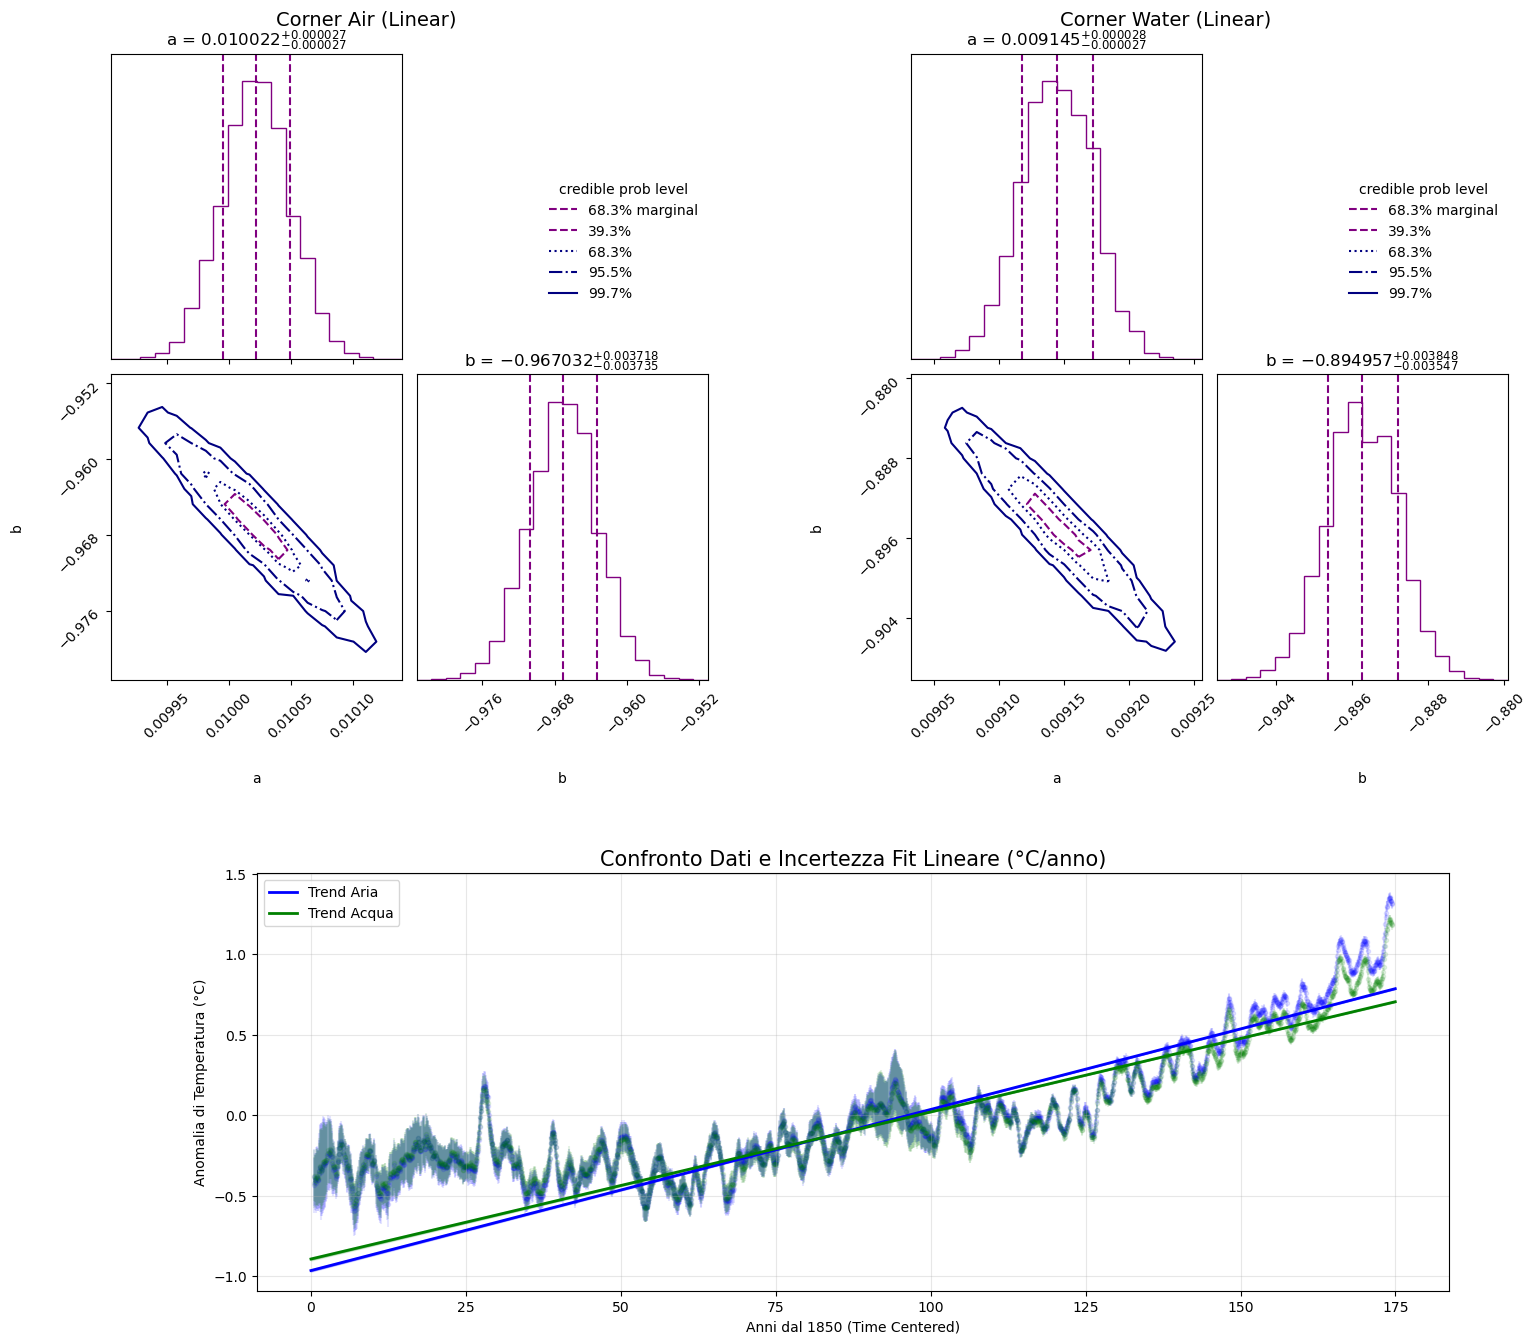

In [10]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b = samples[i]
        band.add(a * t_grid + b)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

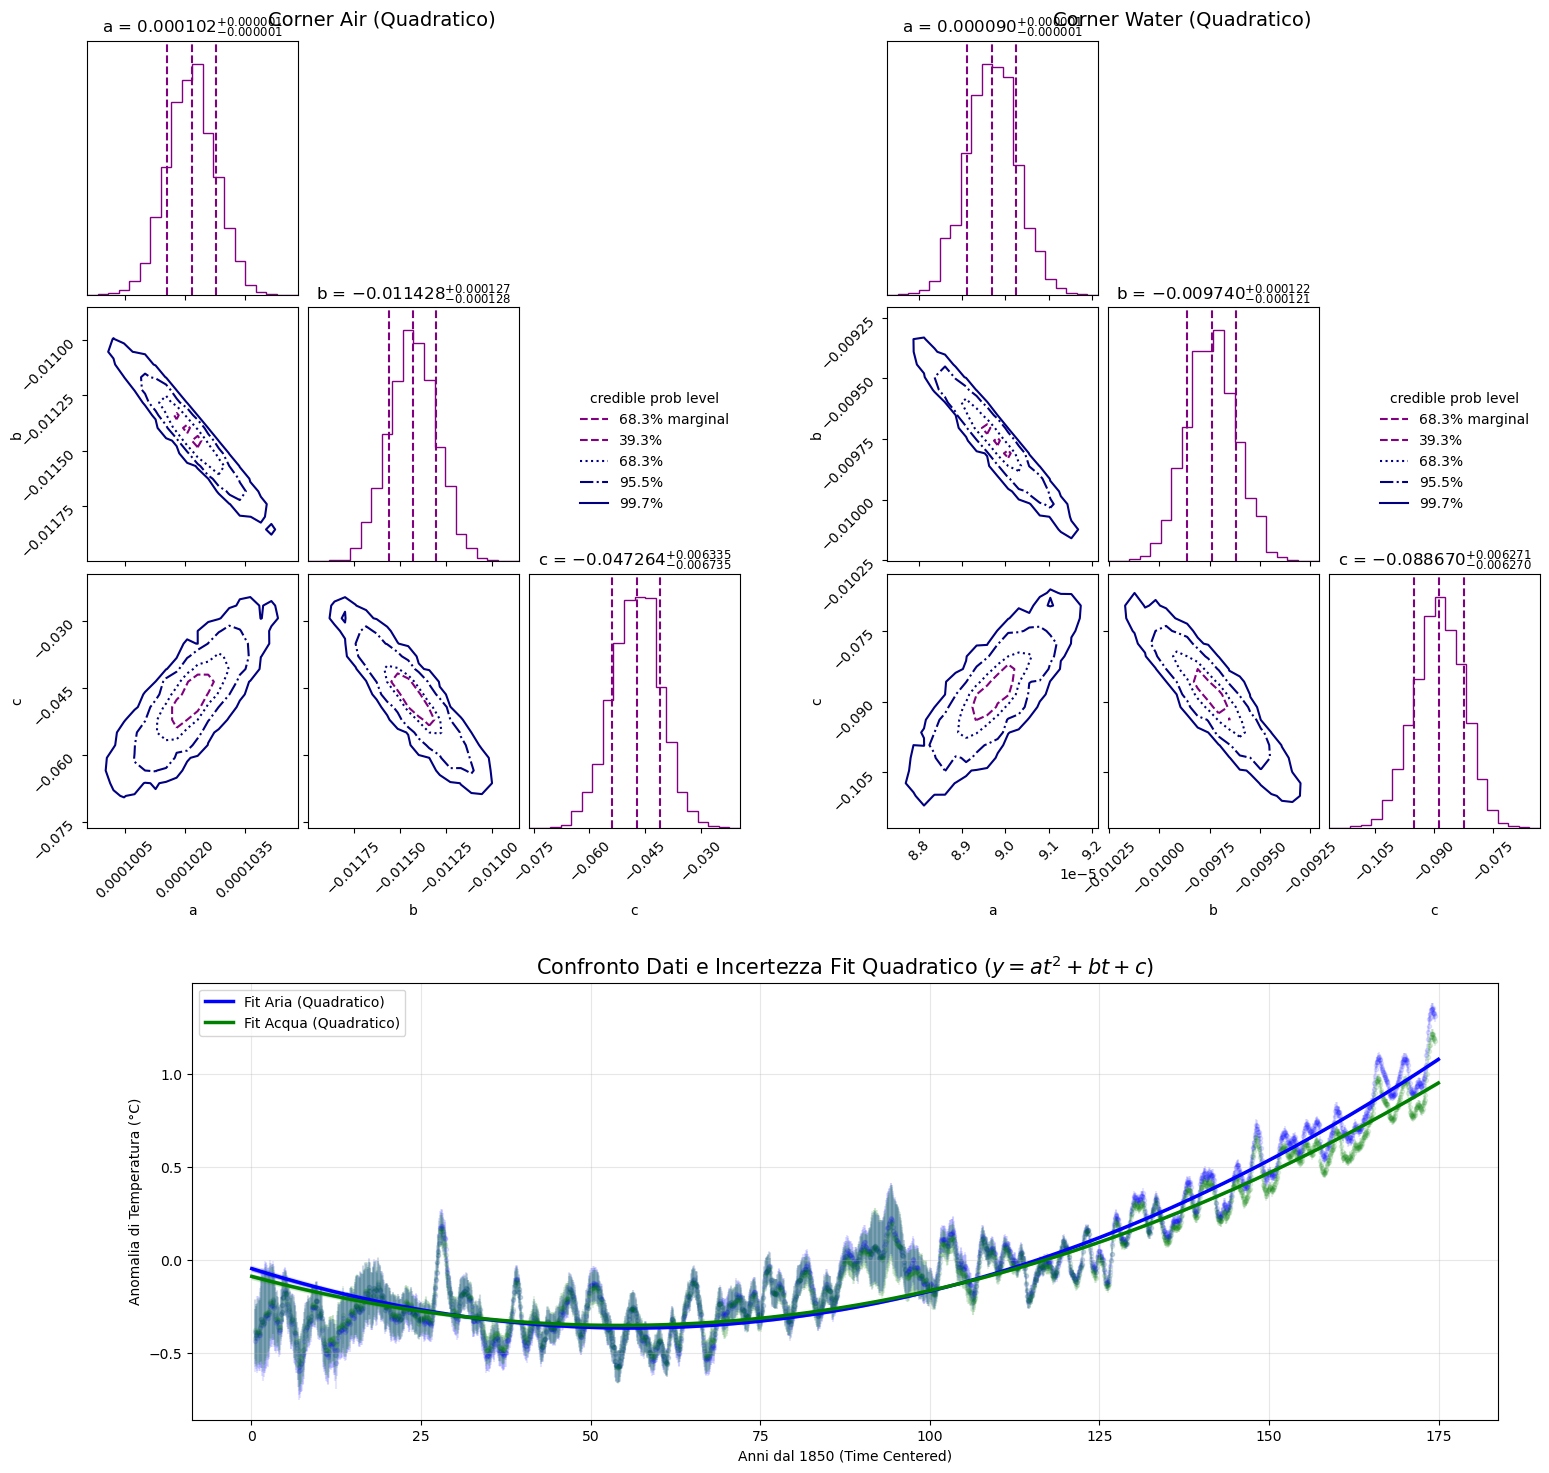

In [11]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b, c = samples[i]
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

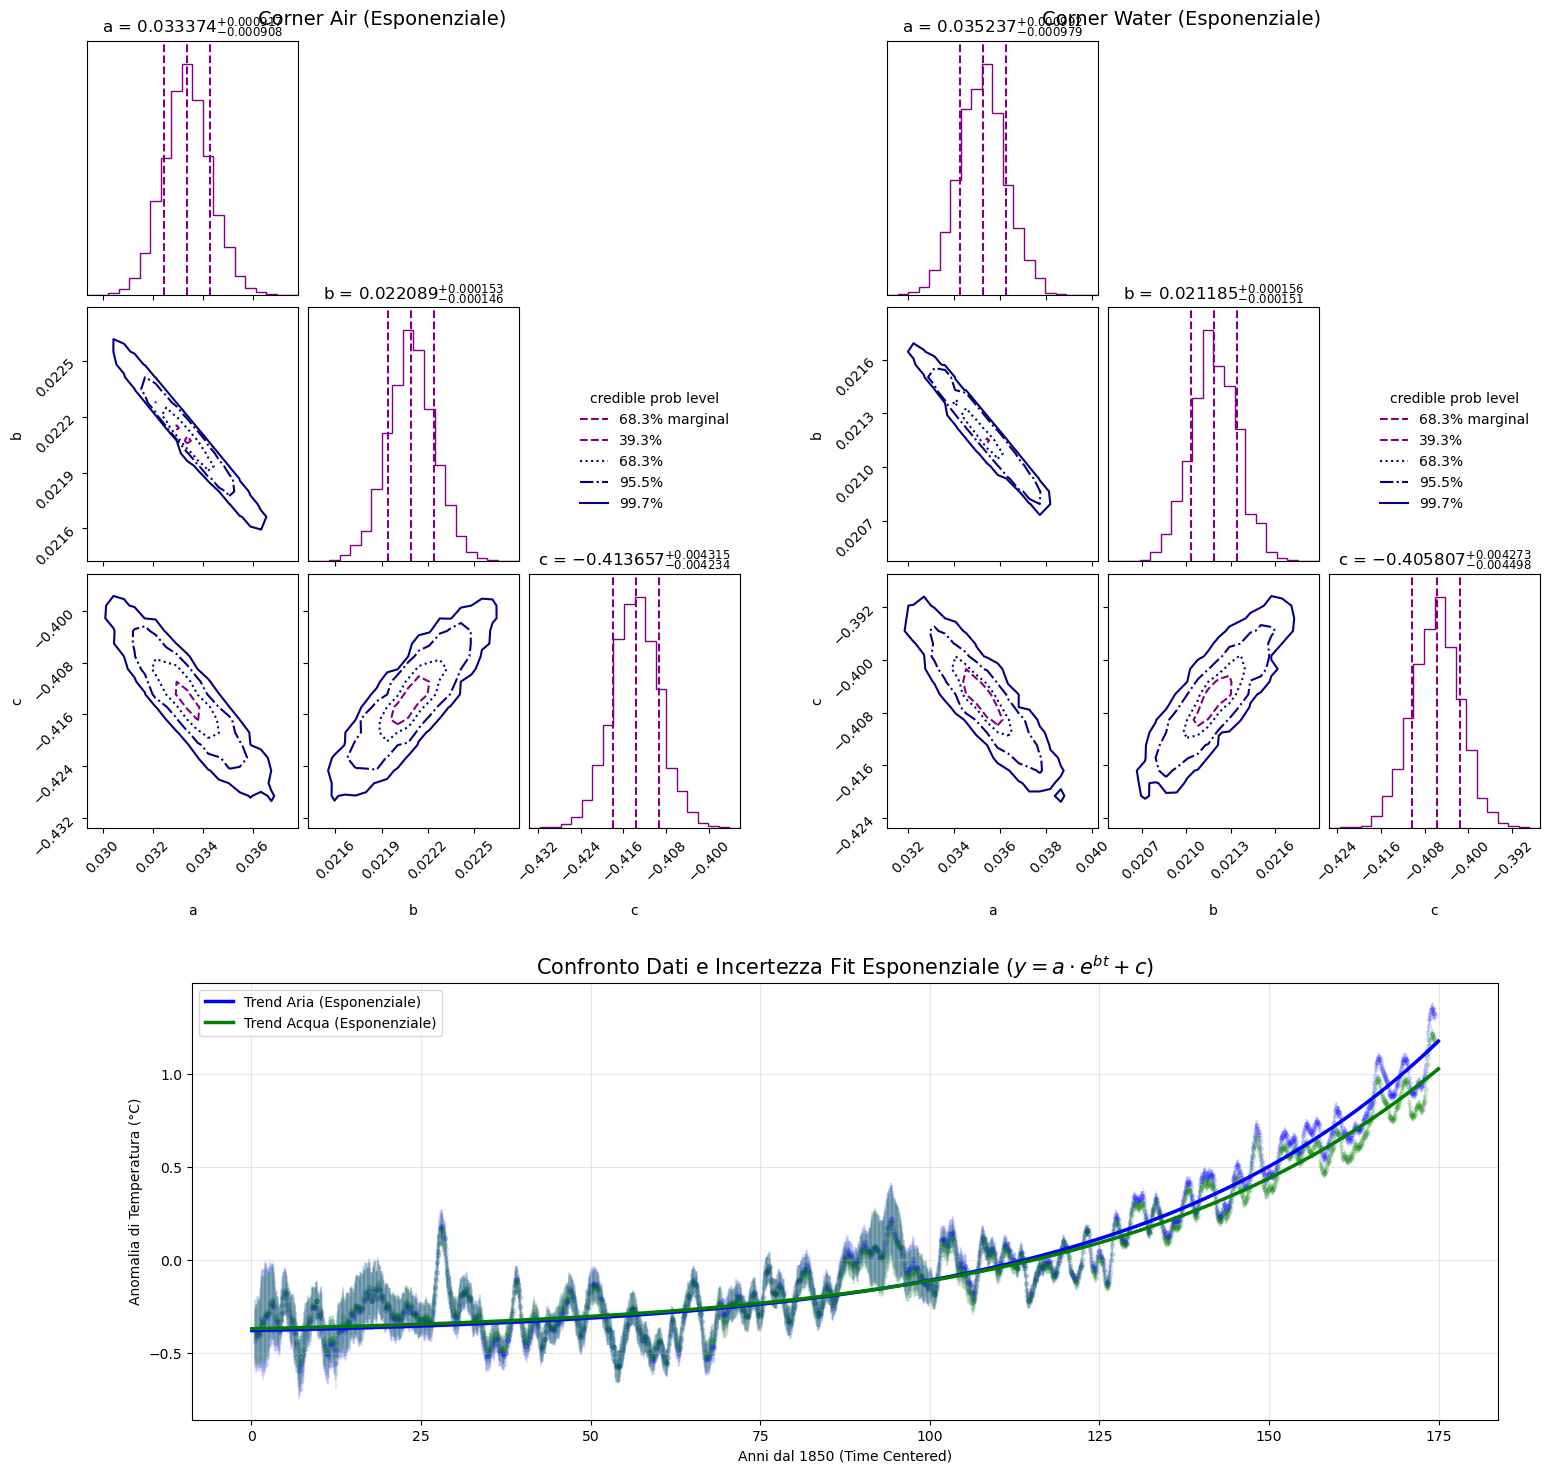

In [15]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b, c = samples[i]
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()